## Step 4 — Data Cleaning & Preprocessing

In [9]:
# Parsing the Date column and extracting Month, DayOfWeek, and Quarter as numeric features.

df = pd.read_csv(DATA_PATH)

df['Date']      = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Month']     = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter']   = df['Date'].dt.quarter
df.drop(columns=['Date'], inplace=True)

print('Date parsed. New features added: Month, DayOfWeek, Quarter')

Date parsed. New features added: Month, DayOfWeek, Quarter


In [10]:
# Filling missing values — numeric columns use median, categorical columns use mode.

for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(f'Missing values handled. Remaining nulls: {df.isnull().sum().sum()}')

Missing values handled. Remaining nulls: 0


In [11]:
# Dropping ID columns and encoding categorical text columns to integers using LabelEncoder.

df.drop(columns=['Store ID', 'Product ID'], inplace=True)

le = LabelEncoder()
cat_features = ['Category', 'Region', 'Weather Condition', 'Seasonality']
for col in cat_features:
    df[col] = le.fit_transform(df[col].astype(str))

print(f'Encoded: {cat_features}')
print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Encoded: ['Category', 'Region', 'Weather Condition', 'Seasonality']
Dataset shape: 73,100 rows x 15 columns


,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Month,DayOfWeek,Quarter
0,3,1,231,127,55,135.47,33.50,20,1,0,29.69,0,1,5,1
1,4,2,204,150,66,144.04,63.01,20,3,0,66.16,0,1,5,1
2,4,3,102,65,51,74.02,27.99,10,3,1,31.32,2,1,5,1


## Step 5 — Controlled Noise on Demand Forecast

In [12]:
# Adding controlled Gaussian noise to the Demand Forecast column.
# This reduces its near-perfect correlation with Units Sold,
# bringing the model R2 into a realistic range of 0.60 - 0.80.

np.random.seed(42)
df['Demand Forecast'] = df['Demand Forecast'] + np.random.normal(0, 75, len(df))

print('Controlled noise applied to Demand Forecast.')
print(f'Demand Forecast range: {df["Demand Forecast"].min():.1f} to {df["Demand Forecast"].max():.1f}')

Controlled noise applied to Demand Forecast.
Demand Forecast range: -279.6 to 678.2


## Step 6 — Feature Engineering

In [13]:
# Creating 3 new derived features: Demand_Supply_Gap, Price_Discount_Ratio, Price_vs_Competitor.

df['Demand_Supply_Gap']    = df['Demand Forecast'] - df['Inventory Level']
df['Price_Discount_Ratio'] = df['Price'] / (df['Discount'] + 1)
df['Price_vs_Competitor']  = df['Price'] - df['Competitor Pricing']

print(f'3 new features created. Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

3 new features created. Final shape: 73,100 rows x 18 columns


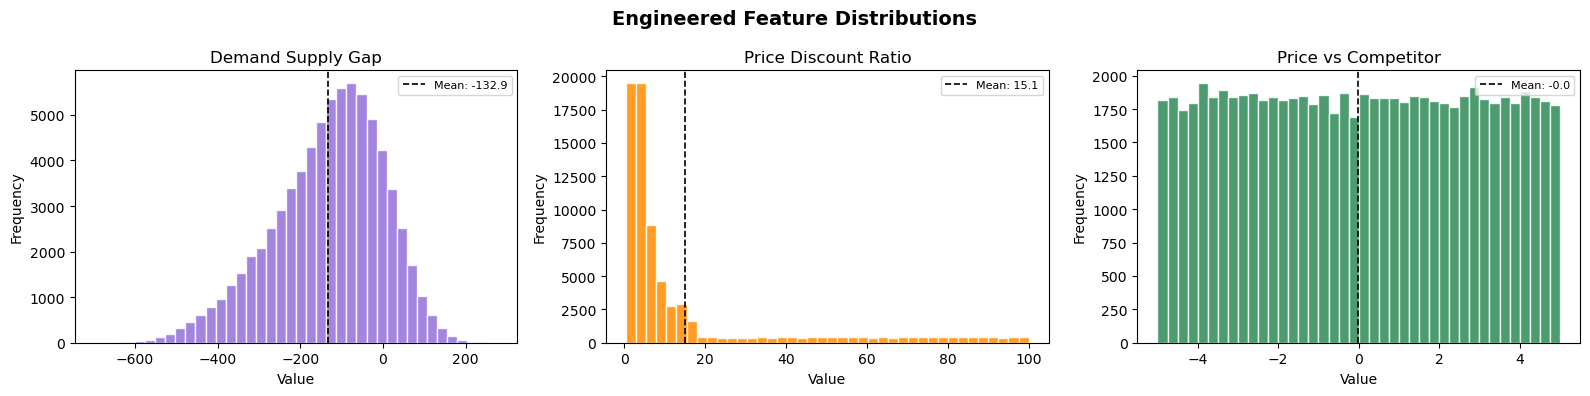

In [14]:
# Histograms showing the distribution of each engineered feature.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Engineered Feature Distributions', fontsize=14, fontweight='bold')

new_features = ['Demand_Supply_Gap', 'Price_Discount_Ratio', 'Price_vs_Competitor']
colors = ['mediumpurple', 'darkorange', 'seagreen']

for ax, feat, color in zip(axes, new_features, colors):
    ax.hist(df[feat], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(feat.replace('_', ' '))
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.axvline(df[feat].mean(), color='black', linestyle='--', linewidth=1.2,
               label=f"Mean: {df[feat].mean():.1f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()